<br> </br>
<font color='darkred' size = 7.5> <center>  <b> Quantitative strategies on high-frequency data </b> </center> </font>
<font color='darkred' size = 5> <center>  6. Assessing strategy performance </center> </font>
<br>
<font size = 5> <center> prof. Piotr Wójcik </center> </font>
<br> 
<font size = 5> <center>  academic year 2025/2026 </center> </font>

In [ ]:
# pip install quantstats

In [4]:
# lets load the needed libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import quantstats as qs
import warnings
warnings.simplefilter(action="ignore", category=UserWarning)  # ignoruje wszystkie ostrzeżenia typu UserWarning

In [5]:
# let's load the data from the previous part
# saved to the parquet file

dataUSA_AAPL_META = pd.read_parquet("dataUSA_AAPL_META_after_lab5.parquet")

dataUSA_AAPL_META.head()

# data includes
# close_AAPL               - close price of Apple Co.
# close_META               - close price of META (Facebook) Co.
# close_AAPL_SMA20         - rolling SMA20 of AAPL close price
# close_AAPL_SMA10         - rolling SMA10 of AAPL close price
# close_AAPL_SMA60         - rolling SMA60 of AAPL close price
# close_AAPL_EMA10         - rolling EMA10 of AAPL close price
# close_AAPL_EMA60         - rolling EMA60 of AAPL close price
# close_AAPL_STD60         - rolling 60 min stdev of AAPL close price
# close_AAPL_MAD60         - rolling 60 min Mean Absolute Difference of AAPL close price
# close_AAPL_MedAD60       - rolling 60 min Median Absolute Difference of AAPL close price

# and position, gross pnl, ntrans and net pnl
# for three different entry techniques
# and two strategies (mom and mr) for each

# none of the tested strategies is profitable in net terms

,close_AAPL,close_META,close_AAPL_SMA20,close_AAPL_SMA10,close_AAPL_SMA60,close_AAPL_EMA10,close_AAPL_EMA60,close_AAPL_STD60,close_AAPL_MAD60,close_AAPL_MedAD60,...,pnl_net2b_mr,position3_mom,position3_mr,pnl_gross3_mom,pnl_gross3_mr,ntrans3,pnl_net3_mom,pnl_net3_mr,close_AAPL_VB_lower,close_AAPL_VB_upper
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-01-02 09:31:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:32:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2025-01-02 09:33:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2025-01-02 09:34:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2025-01-02 09:35:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


### Example 1: Simple Moving Average

Entry Technique - Price-Moving Average Crossover

* We use the 20-minute moving average (MA) for AAPL

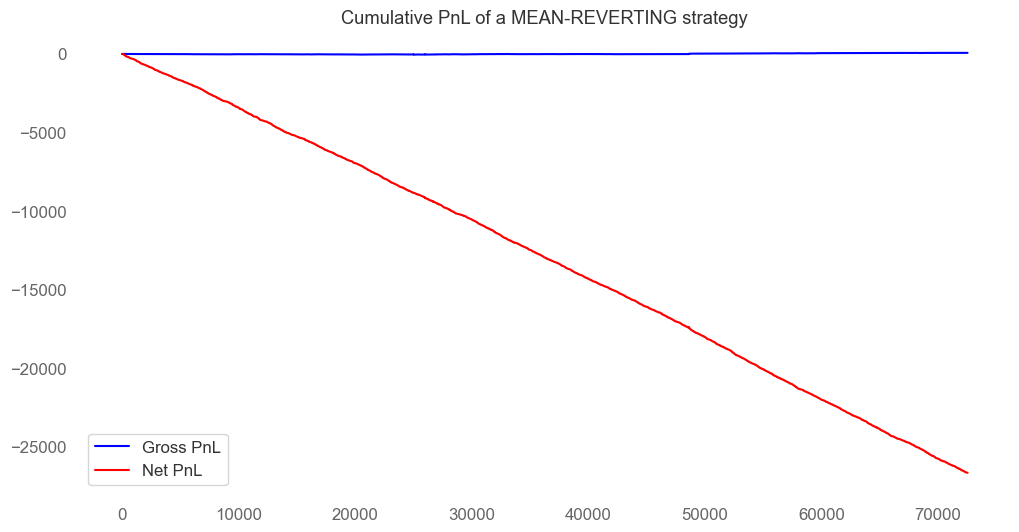

In [6]:
# lets remind a cumulative pnl for a mean-reverting strategy

# lets make a copy of the data for plotting
dataUSA_AAPL_META_plot = dataUSA_AAPL_META.copy()

# reset the index to a column to plot
# without gaps in time series data
dataUSA_AAPL_META_plot.reset_index(inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(
    dataUSA_AAPL_META_plot.index, 
    np.cumsum(dataUSA_AAPL_META['pnl_gross1_mr']), 
    color='blue', label='Gross PnL')
plt.plot(
    dataUSA_AAPL_META_plot.index, 
    np.cumsum(dataUSA_AAPL_META['pnl_net1_mr']), 
    color='red', label='Net PnL')
plt.title("Cumulative PnL of a MEAN-REVERTING strategy")
plt.legend()
plt.grid()

# no chance for profits with this strategy...

In [7]:
# Let's calculate the annualized Sharpe Ratio (SR)

# We will write a simple mySR function
# with 2 parameters:

# x: profit/loss series
# scale: scale, e.g., 252 for daily data

def mySR(x, scale):
    return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)

In [8]:
# Let's check the number of minutes in an average trading day -
# We assumed we weren't trading for the first and last 10 minutes.
# So the strategy works between 9:40 and 15:50.

# Let's save the number of minutes to the object.

TradingMinsInDay = (6.5 * 60 - 2 * 10)

TradingMinsInDay

370.0

In [9]:
# Gross SR for MEAN-REVERTING strategy based on single MA
# mySR(x,scale)
# SELF : returns can be represented as percentage or monetary terms. Monetary terms is preferred.
mySR(x = dataUSA_AAPL_META['pnl_gross1_mr'],
     scale = 252 * TradingMinsInDay)

# positive

np.float64(1.7047767132907945)

In [10]:
# net SR for the same strategy

mySR(dataUSA_AAPL_META['pnl_net1_mr'],
     scale = 252 * TradingMinsInDay)

# no comment...

np.float64(-113.09756391259884)

In [11]:
# Let's add the profit/loss columns in percentage terms
# (as a % of invested capital)

# Since we're assuming the purchase and sale of 1 AAPL share, 
# the invested capital is the AAPL share price at the time 
# beginning of the interval.

# strategy 1
dataUSA_AAPL_META['pnl_gross1_mom_pct'] = (
    dataUSA_AAPL_META['pnl_gross1_mom'] /
    dataUSA_AAPL_META['close_AAPL'].shift(1))
dataUSA_AAPL_META['pnl_net1_mom_pct'] = (
    dataUSA_AAPL_META['pnl_net1_mom'] /
    dataUSA_AAPL_META['close_AAPL'].shift(1))
# It is only converting a PnL series into a return series.
dataUSA_AAPL_META['pnl_gross1_mr_pct'] = (
    dataUSA_AAPL_META['pnl_gross1_mr'] /
    dataUSA_AAPL_META['close_AAPL'].shift(1))
dataUSA_AAPL_META['pnl_net1_mr_pct'] = (
    dataUSA_AAPL_META['pnl_net1_mr'] /
    dataUSA_AAPL_META['close_AAPL'].shift(1))

# strategy 2
dataUSA_AAPL_META['pnl_gross2b_mom_pct'] = (
    dataUSA_AAPL_META['pnl_gross2b_mom'] /
    dataUSA_AAPL_META['close_AAPL'].shift(1))
dataUSA_AAPL_META['pnl_net2b_mom_pct'] = (
    dataUSA_AAPL_META['pnl_net2b_mom'] /
    dataUSA_AAPL_META['close_AAPL'].shift(1))
dataUSA_AAPL_META['pnl_gross2b_mr_pct'] = (
    dataUSA_AAPL_META['pnl_gross2b_mr'] /
    dataUSA_AAPL_META['close_AAPL'].shift(1))
dataUSA_AAPL_META['pnl_net2b_mr_pct'] = (
    dataUSA_AAPL_META['pnl_net2b_mr'] /
    dataUSA_AAPL_META['close_AAPL'].shift(1))

# strategy 3
dataUSA_AAPL_META['pnl_gross3_mom_pct'] = (
    dataUSA_AAPL_META['pnl_gross3_mom'] /
    dataUSA_AAPL_META['close_AAPL'].shift(1))
dataUSA_AAPL_META['pnl_net3_mom_pct'] = (
    dataUSA_AAPL_META['pnl_net3_mom'] /
    dataUSA_AAPL_META['close_AAPL'].shift(1))
dataUSA_AAPL_META['pnl_gross3_mr_pct'] = (
    dataUSA_AAPL_META['pnl_gross3_mr'] /
    dataUSA_AAPL_META['close_AAPL'].shift(1))
dataUSA_AAPL_META['pnl_net3_mr_pct'] = (
    dataUSA_AAPL_META['pnl_net3_mr'] /
    dataUSA_AAPL_META['close_AAPL'].shift(1))


In [12]:
# Let's see if the SR calculated based on percentage profits/losses
# is the same as the SR calculated based on USD profits/losses

mySR(dataUSA_AAPL_META['pnl_gross1_mr_pct'],
     scale = 252 * TradingMinsInDay)

np.float64(1.6481400993831152)

In [13]:
# net SR
mySR(dataUSA_AAPL_META['pnl_net1_mr_pct'],
        scale = 252 * TradingMinsInDay)

# values are very similar

np.float64(-114.26108009128136)

In [14]:
# for calculating various profitability measures
# let's aggregate the calculated profit/loss by days
# for all columns whose names start with "pnl_"
# or "ntrans_"

summary_AAPL_daily = (
    dataUSA_AAPL_META.resample('D') # split by days
    # and aggregate for selected columns
    .agg({col: 'sum' for col in dataUSA_AAPL_META.columns if col.startswith('pnl_') or col.startswith('ntrans')}) # ntrans = number of transactions.
)

summary_AAPL_daily.head()

,pnl_gross1_mom,pnl_gross1_mr,ntrans1,pnl_net1_mom,pnl_net1_mr,pnl_gross2b_mom,pnl_gross2b_mr,ntrans2b,pnl_net2b_mom,pnl_net2b_mr,...,pnl_gross1_mr_pct,pnl_net1_mr_pct,pnl_gross2b_mom_pct,pnl_net2b_mom_pct,pnl_gross2b_mr_pct,pnl_net2b_mr_pct,pnl_gross3_mom_pct,pnl_net3_mom_pct,pnl_gross3_mr_pct,pnl_net3_mr_pct
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-01-02,0.7632,-0.7632,111.0,-165.8725,-167.1275,0.0870,-0.0870,21.0,-31.6075,-31.3925,...,-0.002975,-0.688011,0.000371,-0.129940,-0.000371,-0.129104,0.004402,-0.020287,-0.004402,-0.029090
2025-01-03,0.3273,-0.3273,82.0,-122.6727,-123.3273,-5.6745,5.6745,34.0,-56.6745,-45.3255,...,-0.001352,-0.508741,-0.023385,-0.233768,0.023385,-0.186998,-0.001749,-0.014124,0.001749,-0.010625
2025-01-04,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-01-05,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-01-06,1.5034,-1.5034,68.0,-100.4966,-103.5034,1.0570,-1.0570,20.0,-28.9430,-31.0570,...,-0.006126,-0.423050,0.004328,-0.118240,-0.004328,-0.126896,0.000448,-0.011849,-0.000448,-0.012745


In [ ]:
# SELF :
summary_AAPL_daily.pnl_gross1_mr_pct

timestamp
2025-01-02   -0.002975
2025-01-03   -0.001352
2025-01-04    0.000000
2025-01-05    0.000000
2025-01-06   -0.006126
                ...   
2025-09-26   -0.001581
2025-09-27    0.000000
2025-09-28    0.000000
2025-09-29    0.007141
2025-09-30    0.003086
Freq: D, Name: pnl_gross1_mr_pct, Length: 272, dtype: float64

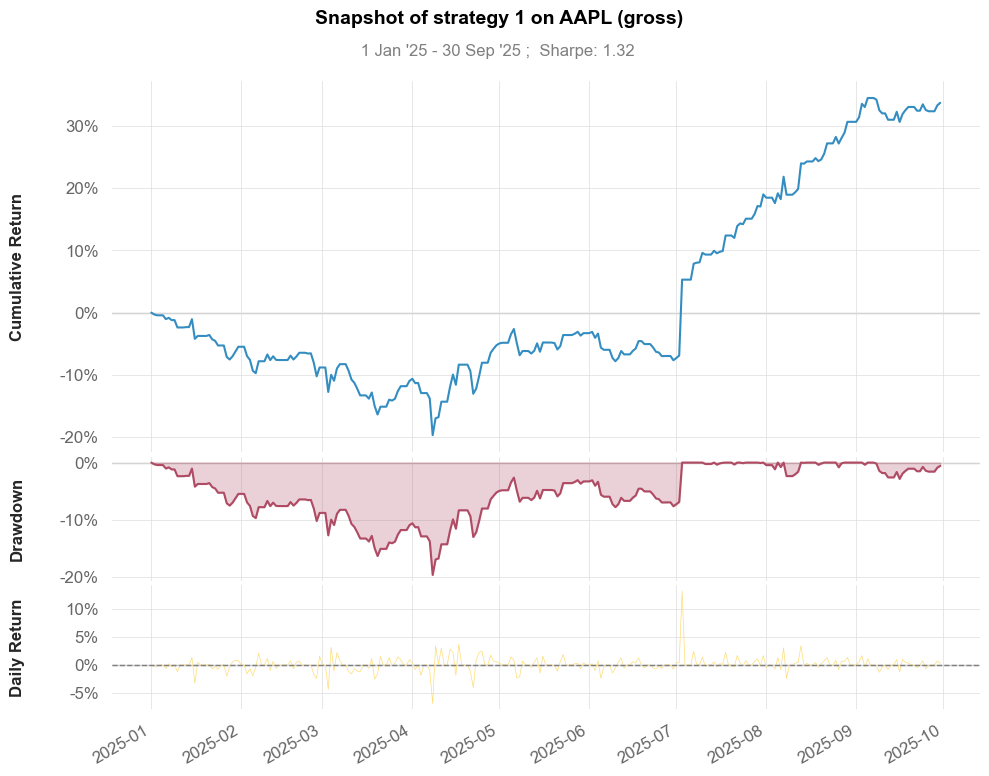

In [14]:
# Let's see the summary of strategy 1 in a MEAN-REVERTING variant
# - equity curve, drawdown, and daily profits/losses

# !! IMPORTANT !!
# functions from qs library require a series of returns
# i.e., profit/loss in percentage terms w/o missing values

returns_strategy = summary_AAPL_daily['pnl_gross1_mr_pct'].dropna()

qs.plots.snapshot(returns_strategy, 
                  title = "Snapshot of strategy 1 on AAPL (gross)")

In [15]:
# function for SR from the quantstats package

sharpe = qs.stats.sharpe(returns_strategy)
# values will be slightly different from calculations on minute data

# alternative measures
calmar = qs.stats.calmar(returns_strategy)
sortino = qs.stats.sortino(returns_strategy)
omega = qs.stats.omega(returns_strategy)

print(f"Sharpe Ratio: {sharpe:.4f}")
print(f"Calmar Ratio: {calmar:.4f}")
print(f"Sortino Ratio: {sortino:.4f}")
print(f"Omega Ratio: {omega:.4f}")


Sharpe Ratio: 1.3273
Calmar Ratio: 1.5947
Sortino Ratio: 2.2697
Omega Ratio: 1.3765


In [18]:
# Calculation of the maximum drawdown for the entire period.

qs.stats.max_drawdown(returns_strategy)

# -19.5%

-0.1946523588747655

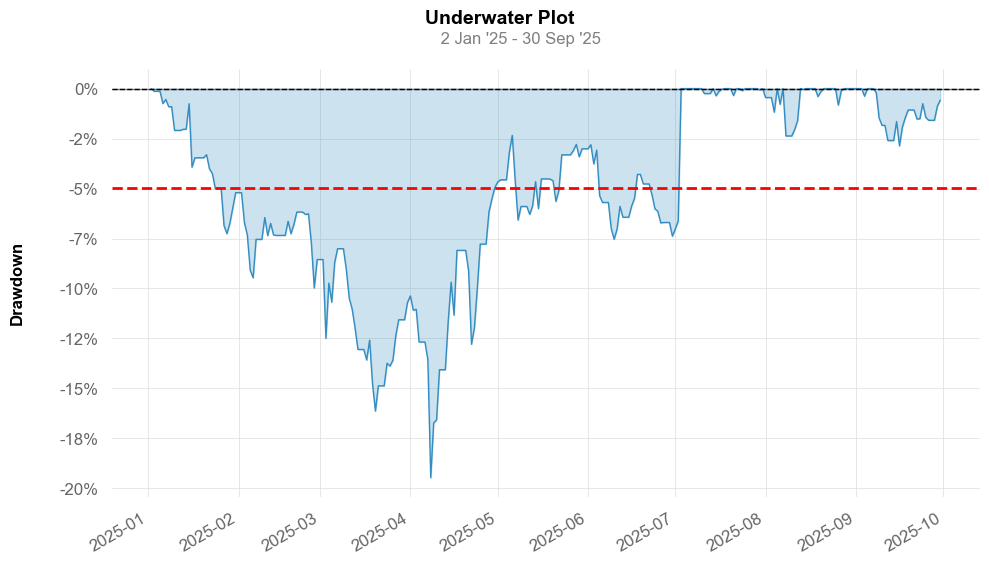

In [19]:
# Visualization of the drawdown ("underwater" plot)
qs.plots.drawdown(returns_strategy, figsize=(10, 6))

### Summarizing of many strategies

In [20]:
# Let's calculate all the above metrics 
# for all strategies used on AAPL
# using a user-defined function

def calculate_metrics(df, strategy_col):
    returns = df[strategy_col].dropna()
    sharpe = qs.stats.sharpe(returns)
    calmar = qs.stats.calmar(returns)
    sortino = qs.stats.sortino(returns)
    omega = qs.stats.omega(returns)
    max_drawdown = qs.stats.max_drawdown(returns)
    
    return {
        'Sharpe Ratio': sharpe,
        'Calmar Ratio': calmar,
        'Sortino Ratio': sortino,
        'Omega Ratio': omega,
        'Max Drawdown': max_drawdown
    }

$$
\text{Sharpe} = \frac{\mathbb{E}[R]}{\sigma(R)}
$$

$$
\text{Calmar} = 
\frac{\mathbb{E}[R_{\text{annual}}]}{\left|\text{Max Drawdown}\right|}
$$

$$
\text{Sortino} = 
\frac{\mathbb{E}[R]}{\sigma(R_{R<0})}
$$

$$
\Omega = 
\frac{\int_{0}^{\infty} \left(1 - F_R(r)\right)\, dr}
     {\int_{-\infty}^{0} F_R(r)\, dr}
$$

$$
\text{MDD} = 
\max_{t}
\left(
\frac{P_{\text{peak up to } t} - P_t}
     {P_{\text{peak up to } t}}
\right)
$$


In [21]:
# Their % results are stored in columns starting with "pnl_"
# and ending with "_pct"

# List of strategy columns
strategy_columns = [col for col in summary_AAPL_daily.columns if col.startswith('pnl_') and col.endswith('_pct')]

# Calculating metrics for each strategy
metrics = {}
for col in strategy_columns:
    metrics[col] = calculate_metrics(summary_AAPL_daily, col)

# Conversion of results to DataFrame
metrics_df = pd.DataFrame(metrics).T

# Displaying the results
print(metrics_df)

                     Sharpe Ratio  Calmar Ratio  Sortino Ratio  Omega Ratio  \
pnl_gross1_mom_pct      -1.327333     -0.644854      -1.632209     0.726486   
pnl_net1_mom_pct       -21.705336     -1.000000     -12.821520     0.000000   
pnl_gross1_mr_pct        1.327333      1.594714       2.269690     1.376489   
pnl_net1_mr_pct        -22.085219     -1.000000     -12.898215     0.000000   
pnl_gross2b_mom_pct     -0.456084     -0.549241      -0.584060     0.884722   
pnl_net2b_mom_pct      -17.989065     -1.000000     -11.914314     0.001481   
pnl_gross2b_mr_pct       0.456084      0.500679       0.732796     1.130299   
pnl_net2b_mr_pct       -20.283481     -1.000000     -12.509849     0.000000   
pnl_gross3_mom_pct       0.768088      1.302914       1.838055     1.282289   
pnl_net3_mom_pct       -10.608892     -0.990038      -9.487328     0.062771   
pnl_gross3_mr_pct       -0.768088     -0.609961      -0.846130     0.779855   
pnl_net3_mr_pct        -12.566777     -0.992071     

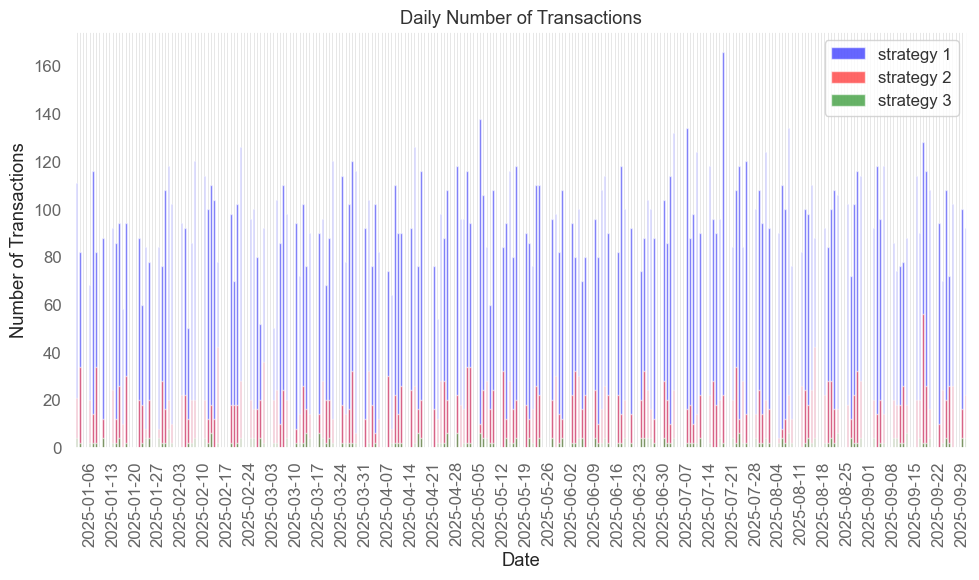

In [22]:
# display the number of transactions for each strategy
# day by day in a bar chart

plt.figure(figsize = (10, 6))
summary_AAPL_daily['ntrans1'].plot(kind = 'bar', # type of plot
                                   color = 'blue', # color of bars
                                   alpha = 0.6, # transparency
                                   label = 'strategy 1')
summary_AAPL_daily['ntrans2b'].plot(kind = 'bar', 
                                    color = 'red', 
                                    alpha = 0.6,
                                    label = 'strategy 2')
summary_AAPL_daily['ntrans3'].plot(kind = 'bar',
                                   color = 'green',
                                   alpha = 0.6,
                                   label = 'strategy 3')

# labels on X axis only for Mondays (weekday == 0)
plt.xticks(
    ticks = np.arange(len(summary_AAPL_daily.index)),
    labels = [date.strftime('%Y-%m-%d') if date.weekday() == 0 else '' for date in summary_AAPL_daily.index],
    rotation=90)

plt.title('Daily Number of Transactions')
plt.ylabel('Number of Transactions')
plt.xlabel('Date')
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# Let's calculate the average daily number of transactions
# for each strategy (excluding weekends,
# because the stock market is closed then)

# Let's ignore weekends (Saturday = 5, Sunday = 6)
weekdays_only = summary_AAPL_daily[summary_AAPL_daily.index.dayofweek < 5]

avg_ntrans = weekdays_only[[col for col in weekdays_only.columns if col.startswith('ntrans')]].mean()
print("Average daily number of transactions for each strategy:")
print(avg_ntrans)

Average daily number of transactions for each strategy:
ntrans1     91.850515
ntrans2b    19.231959
ntrans3      2.443299
dtype: float64


# Exercises 6

Perform similar analyses for the assets selected and analyzed in previous labs.

# Exercise 6.1

* Load previously saved data with positions and PnL 
* Calculate the gross and net SR for a strategy based on a single moving average (SMA or EMA)
* Calculate and plot the maximum drawdown on the chart

In [ ]:
# place for solution to Exercise 6.1

# Exercise 6.2

* Calculate the gross and net SR for a strategy based on two moving medians
* Calculate and plot the maximum drawdown on the chart


In [ ]:
# place for solution to Exercise 6.2

# Exercise 6.3

* Calculate the gross and net SR for a strategy based on the volatility breakout model
* Calculate and plot the maximum drawdown on the chart

In [ ]:
# place for solution to Exercise 6.3